<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab%205%20SVM%20%E2%80%94%20Margins%2C%20Kernels%2C%20and%20a%20Grid%20Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5 — Margins, Kernels, and a Grid Search

**Machine Learning · Week 5**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Visualize margins, support vectors and decision boundaries — 2. Explain and demonstrate the effect of C and gamma — 3. Select a kernel on evidence and tune interacting hyperparameters with grid search — 4. Diagnose the silent failure of an unscaled SVM — |
| **Datasets** | Synthetic blobs and moons (for seeing) · Breast Cancer Wisconsin (for a real workflow) · a constructed patient dataset (for the scaling trap) |
| **Grading** | Exercises 1–6 + AI-usage disclosure · self-checks give instant feedback |

> **Today you get to see the geometry.** Every model so far has been judged by a number. An SVM's boundary can be *drawn* — along with its margin and the handful of points that define it. And at the end, you'll watch an unscaled SVM fail without complaining, which is the most useful thing this lab can teach you.

⚠️ **First:** File → Save a copy in Drive, rename to `Lab5_<your_student_id>`.

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_blobs, make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

RNG_SEED = 42
np.random.seed(RNG_SEED)

CMAP_PT = ListedColormap(["#15807E", "#E8912D"])
CMAP_BG = ListedColormap(["#DCEEED", "#FCEBDC"])
print("Setup complete ✔")

Setup complete ✔


---
## Part 1 · See the margin

Two well-separated blobs, and a linear SVM. The helper below draws three things most people never look at: the boundary, the **margin** (the "street"), and the **support vectors**.

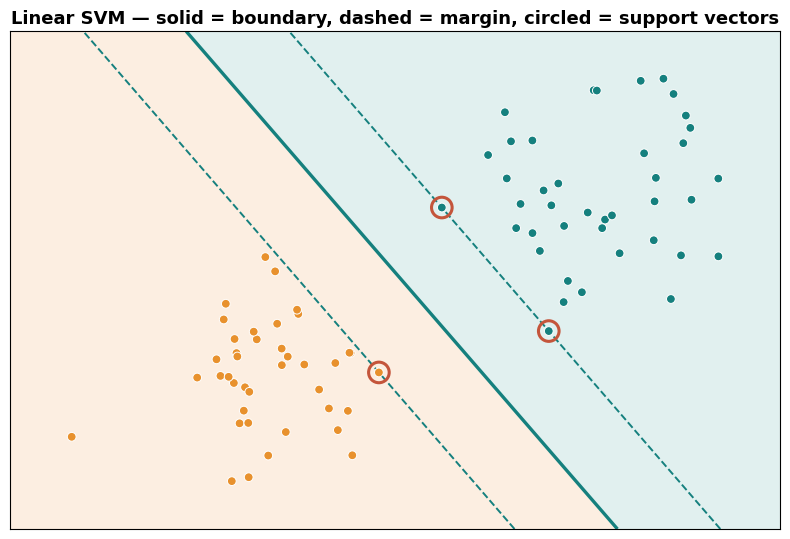

support vectors: 3 out of 80 training points
per class: [2 1]


In [2]:
X, y = make_blobs(n_samples=80, centers=2, cluster_std=1.2, random_state=3)

def plot_svm(model, X, y, ax, title="", show_margin=True):
    """Draw decision boundary, margin lines, and support vectors."""
    h = 0.02
    xx, yy = np.meshgrid(np.arange(X[:,0].min()-1, X[:,0].max()+1, h),
                         np.arange(X[:,1].min()-1, X[:,1].max()+1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_BG, alpha=0.85)
    if show_margin:
        D = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contour(xx, yy, D, levels=[-1, 0, 1], colors="#15807E",
                   linestyles=["--", "-", "--"], linewidths=[1.4, 2.4, 1.4])
    ax.scatter(X[:,0], X[:,1], c=y, cmap=CMAP_PT, s=40, edgecolors="white", linewidths=0.7, zorder=4)
    sv = model.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=220, facecolors="none", edgecolors="#C4553B",
               linewidths=2.2, zorder=5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

svm_lin = SVC(kernel="linear", C=1.0).fit(X, y)

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_svm(svm_lin, X, y, ax, "Linear SVM — solid = boundary, dashed = margin, circled = support vectors")
plt.tight_layout(); plt.show()

print(f"support vectors: {len(svm_lin.support_vectors_)} out of {len(X)} training points")
print(f"per class: {svm_lin.n_support_}")

**Three support vectors out of eighty.** That is the claim from the lecture, verified: the boundary is determined by a handful of points and nothing else.

Let's prove it properly — delete every point that is *not* a support vector, refit, and compare.

In [3]:
sv_idx = svm_lin.support_          # indices of the support vectors
X_sv, y_sv = X[sv_idx], y[sv_idx]

svm_sv_only = SVC(kernel="linear", C=1.0).fit(X_sv, y_sv)

print(f"trained on all {len(X)} points : w = {svm_lin.coef_[0].round(4)},  b = {svm_lin.intercept_[0]:.4f}")
print(f"trained on only {len(X_sv)} SVs  : w = {svm_sv_only.coef_[0].round(4)},  b = {svm_sv_only.intercept_[0]:.4f}")
same = np.allclose(svm_lin.coef_, svm_sv_only.coef_, atol=1e-3) and \
       np.allclose(svm_lin.intercept_, svm_sv_only.intercept_, atol=1e-3)
print(f"\nIdentical boundary from 3 points instead of 80: {'✔ YES' if same else 'not quite — check C'}")

trained on all 80 points : w = [-0.5996 -0.4029],  b = -0.4609
trained on only 3 SVs  : w = [-0.5998 -0.403 ],  b = -0.4611

Identical boundary from 3 points instead of 80: ✔ YES


---
## Part 2 · Sweep C — watch the street narrow

The lecture's claim: as C rises, the fine for violations rises, the model tolerates less, the margin shrinks, and fewer points end up as support vectors. Let's measure all three at once.

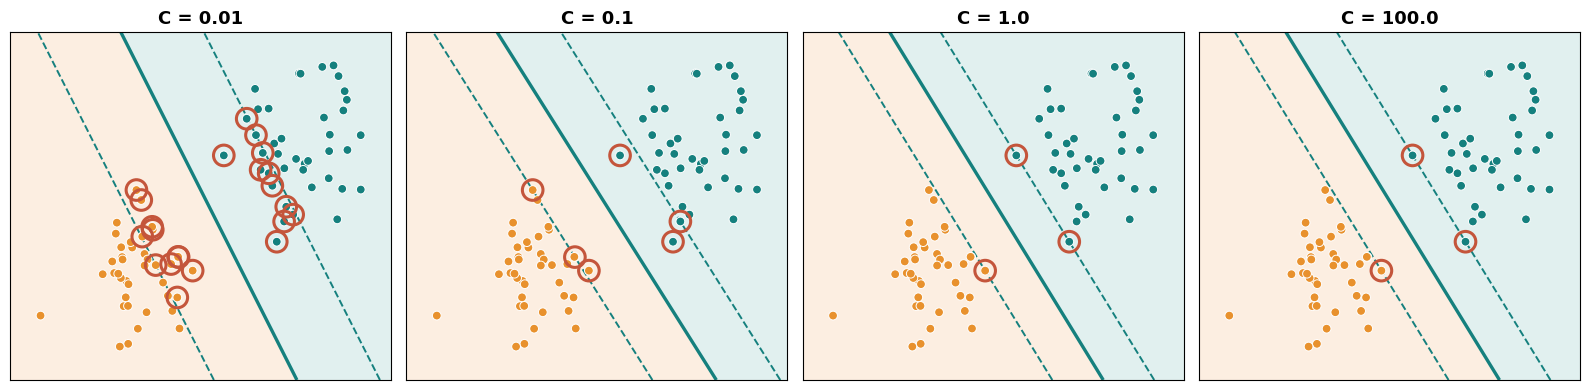

,C,half-margin (1/||w||),street width (2/||w||),support vectors
0,0.01,2.378,4.755,22
1,0.10,1.723,3.446,6
2,1.00,1.384,2.769,3
3,100.00,1.384,2.769,3


In [4]:
rows = []
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, C_val in zip(axes, [0.01, 0.1, 1.0, 100.0]):
    m = SVC(kernel="linear", C=C_val).fit(X, y)
    w = m.coef_[0]
    half_margin = 1 / np.sqrt(np.sum(w ** 2))     # boundary -> kerb
    rows.append({"C": C_val,
                 "half-margin (1/||w||)": round(half_margin, 3),
                 "street width (2/||w||)": round(2 * half_margin, 3),
                 "support vectors": len(m.support_vectors_)})
    plot_svm(m, X, y, ax, f"C = {C_val}")
plt.tight_layout(); plt.show()

pd.DataFrame(rows)

Read the table, not just the pictures. As C goes up the street narrows and the support-vector count falls — two independent signals telling the same story.

Notice also that the numbers **stop changing** past a certain C. Once the fine is high enough that the model already refuses every violation it can, raising it further changes nothing: this data is separable, so it reaches the hard-margin solution and stays there.

> ⚠️ **The direction that trips people up:** large C = *less* regularization. C is the **fine** for being wrong, not the freedom to be wrong. A big fine makes a nervous model.

---
## Part 3 · Break a linear kernel — then fix it

Blobs are easy. Real problems are not. Here are two interleaving crescents that no straight line can separate.

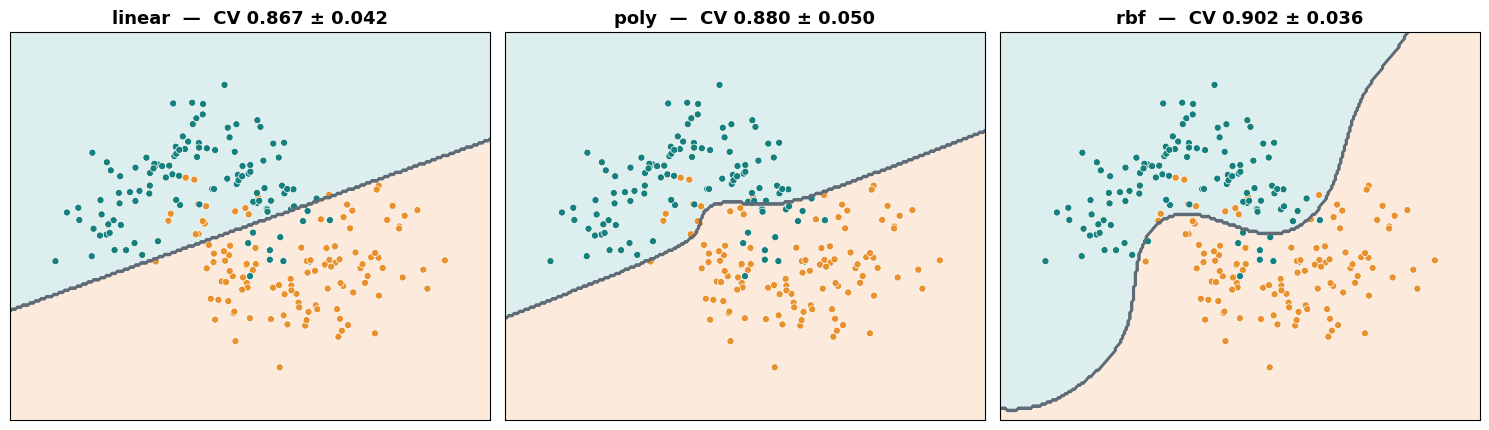

linear   CV = 0.867 ± 0.042
poly     CV = 0.880 ± 0.050
rbf      CV = 0.902 ± 0.036


In [5]:
Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=RNG_SEED)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    Xm, ym, test_size=0.25, stratify=ym, random_state=RNG_SEED)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
kernel_scores = {}
for ax, kern in zip(axes, ["linear", "poly", "rbf"]):
    pipe = make_pipeline(StandardScaler(), SVC(kernel=kern, random_state=RNG_SEED))
    cv = cross_val_score(pipe, Xm_tr, ym_tr, cv=5)
    kernel_scores[kern] = (cv.mean(), cv.std())
    pipe.fit(Xm_tr, ym_tr)
    # plot in original space
    h = 0.02
    xx, yy = np.meshgrid(np.arange(Xm[:,0].min()-.5, Xm[:,0].max()+.5, h),
                         np.arange(Xm[:,1].min()-.5, Xm[:,1].max()+.5, h))
    Z = pipe.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_BG)
    ax.contour(xx, yy, Z, colors="#5F6B76", linewidths=1.1)
    ax.scatter(Xm_tr[:,0], Xm_tr[:,1], c=ym_tr, cmap=CMAP_PT, s=26,
               edgecolors="white", linewidths=0.5)
    ax.set_title(f"{kern}  —  CV {cv.mean():.3f} ± {cv.std():.3f}", fontsize=13, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

for k, (mu, sd) in kernel_scores.items():
    print(f"{k:8s} CV = {mu:.3f} ± {sd:.3f}")

The linear kernel does what it can — a straight cut through curved data. RBF bends around the crescents and wins.

But look at the **spreads** before declaring victory. The gaps here are a few percentage points with fold-to-fold variation of similar size. The honest sentence is "RBF is ahead, and the margin over the others is within the noise" — not "RBF is 3.5% better."

---
## Part 4 · Tune gamma — from over-smooth to islands

Gamma controls how far each point's influence reaches. Watch what it does to the boundary **and** to the train-versus-CV gap.

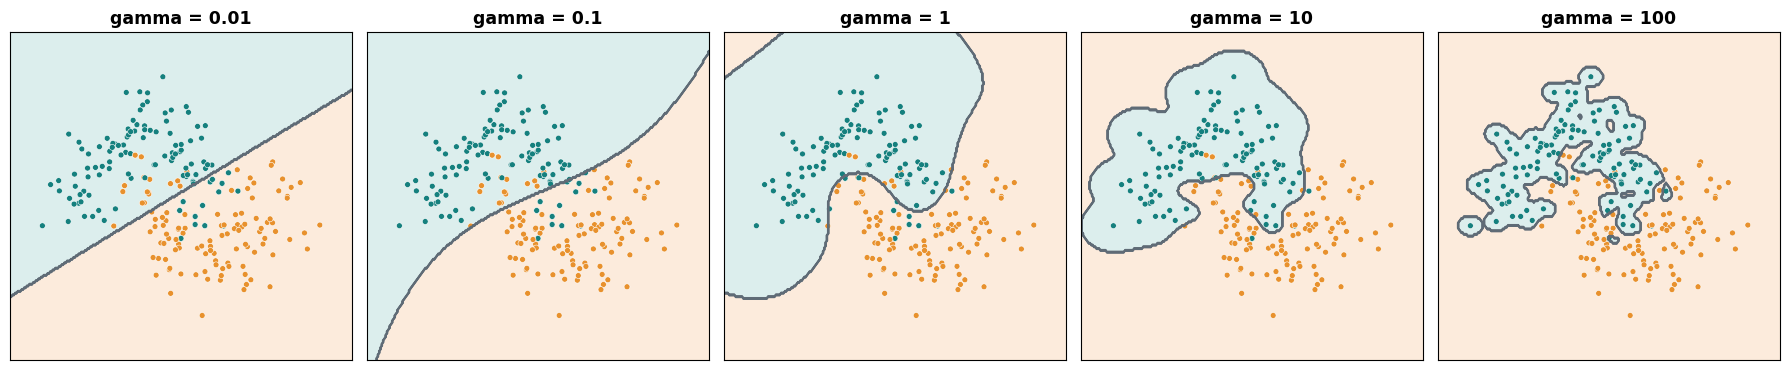

,gamma,train,CV mean,gap
0,0.01,0.867,0.858,0.009
1,0.10,0.871,0.867,0.004
2,1.00,0.916,0.898,0.018
3,10.00,0.960,0.916,0.044
4,100.00,0.987,0.849,0.138


In [6]:
gamma_rows = []
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
for ax, g in zip(axes, [0.01, 0.1, 1, 10, 100]):
    pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma=g, random_state=RNG_SEED))
    cv = cross_val_score(pipe, Xm_tr, ym_tr, cv=5)
    pipe.fit(Xm_tr, ym_tr)
    train_acc = pipe.score(Xm_tr, ym_tr)
    gamma_rows.append({"gamma": g, "train": round(train_acc, 3),
                       "CV mean": round(cv.mean(), 3), "gap": round(train_acc - cv.mean(), 3)})
    h = 0.02
    xx, yy = np.meshgrid(np.arange(Xm[:,0].min()-.5, Xm[:,0].max()+.5, h),
                         np.arange(Xm[:,1].min()-.5, Xm[:,1].max()+.5, h))
    Z = pipe.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=CMAP_BG)
    ax.contour(xx, yy, Z, colors="#5F6B76", linewidths=1.0)
    ax.scatter(Xm_tr[:,0], Xm_tr[:,1], c=ym_tr, cmap=CMAP_PT, s=18,
               edgecolors="white", linewidths=0.4)
    ax.set_title(f"gamma = {g}", fontsize=12.5, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

pd.DataFrame(gamma_rows)

Read the **gap** column — it is the diagnosis, exactly as with `max_depth` last week.

At tiny gamma the boundary is nearly straight and both scores are low: underfitting. As gamma rises the model gets more flexible and both scores improve. Then at the far end training accuracy keeps climbing while CV **falls** — the boundary has broken into islands around individual points. That is memorization, and you have now seen the same pathology four times: K = 1, an unpruned tree, a huge C, and a huge gamma.

---
## Part 5 · The real workflow: GridSearchCV

C and gamma **interact** — the best gamma depends on which C you picked. Tuning them one at a time is not enough, so we search the grid.

Real data now: Breast Cancer Wisconsin, 569 tumours, 30 features.

In [7]:
data = load_breast_cancer()
Xc, yc = data.data, data.target
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.25, stratify=yc, random_state=RNG_SEED)
print("train:", Xc_tr.shape, "| test:", Xc_te.shape, "(locked away until the end)")

param_grid = {
    "svc__C":     [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1],
}
grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", random_state=RNG_SEED))]),
    param_grid, cv=5, n_jobs=-1, return_train_score=True)
grid.fit(Xc_tr, yc_tr)

print(f"\nbest parameters : {grid.best_params_}")
print(f"best CV score   : {grid.best_score_:.4f}")
print(f"combinations tried: {len(grid.cv_results_['params'])}  × 5 folds = {len(grid.cv_results_['params'])*5} fits")

train: (426, 30) | test: (143, 30) (locked away until the end)

best parameters : {'svc__C': 10, 'svc__gamma': 0.001}
best CV score   : 0.9765
combinations tried: 16  × 5 folds = 80 fits


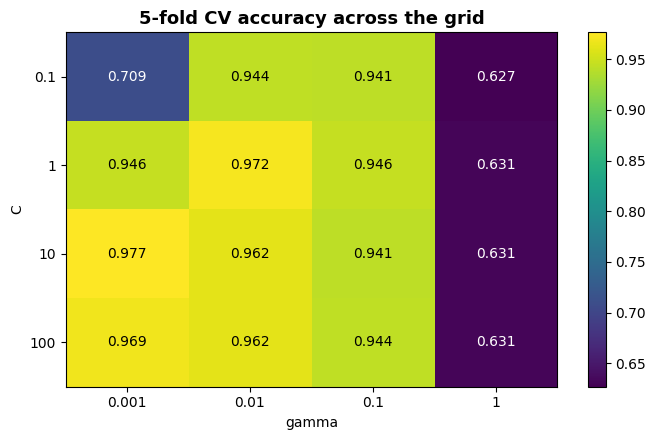

In [8]:
# the whole grid as a heatmap — see how C and gamma interact
scores = grid.cv_results_["mean_test_score"].reshape(len(param_grid["svc__C"]),
                                                     len(param_grid["svc__gamma"]))
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(scores, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(param_grid["svc__gamma"]))); ax.set_xticklabels(param_grid["svc__gamma"])
ax.set_yticks(range(len(param_grid["svc__C"])));     ax.set_yticklabels(param_grid["svc__C"])
ax.set_xlabel("gamma"); ax.set_ylabel("C")
ax.set_title("5-fold CV accuracy across the grid", fontsize=13, fontweight="bold")
for i in range(scores.shape[0]):
    for j in range(scores.shape[1]):
        ax.text(j, i, f"{scores[i,j]:.3f}", ha="center", va="center",
                color="white" if scores[i,j] < scores.max()-0.05 else "black", fontsize=10)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

**Look at the shape of the heatmap, not just the winner.** Good scores form a diagonal band: when gamma goes down, the best C goes up. That is what "the parameters interact" means, drawn — and it is why sweeping one at a time would have missed the best combination.

---
## Part 6 · The scaling trap

The lecture warned that an unscaled SVM fails **silently**. Let's build the exact situation from Activity 2, case C: patient data where age carries the signal and income is pure noise on a huge scale.

In [9]:
rng = np.random.default_rng(7)
n = 400
age    = rng.uniform(20, 90, n)
target = (age > 55).astype(int)           # the signal is entirely in age
age    = age + rng.normal(0, 4, n)        # noisy but informative
income = rng.uniform(0, 2_000_000, n)     # huge scale, ZERO signal
Xp = np.column_stack([age, income])

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(
    Xp, target, test_size=0.25, stratify=target, random_state=RNG_SEED)

svm_raw    = SVC(kernel="rbf", random_state=RNG_SEED).fit(Xp_tr, yp_tr)
svm_scaled = make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=RNG_SEED)).fit(Xp_tr, yp_tr)

cv_raw = cross_val_score(SVC(kernel="rbf", random_state=RNG_SEED), Xp_tr, yp_tr, cv=5)
cv_scl = cross_val_score(make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=RNG_SEED)),
                         Xp_tr, yp_tr, cv=5)

majority = max(np.bincount(yp_te)) / len(yp_te)
print(f"majority-class baseline : {majority:.3f}   <- predicting one class for everything")
print(f"UNSCALED  RBF  CV       : {cv_raw.mean():.3f}")
print(f"SCALED    RBF  CV       : {cv_scl.mean():.3f}")
print(f"difference              : {cv_scl.mean() - cv_raw.mean():+.3f}")
print("\nprediction counts on the test set (unscaled):",
      dict(zip(*np.unique(svm_raw.predict(Xp_te), return_counts=True))))
print("prediction counts on the test set (scaled)  :",
      dict(zip(*np.unique(svm_scaled.predict(Xp_te), return_counts=True))))

majority-class baseline : 0.520   <- predicting one class for everything
UNSCALED  RBF  CV       : 0.517
SCALED    RBF  CV       : 0.943
difference              : +0.427

prediction counts on the test set (unscaled): {np.int64(0): np.int64(17), np.int64(1): np.int64(83)}
prediction counts on the test set (scaled)  : {np.int64(0): np.int64(46), np.int64(1): np.int64(54)}


**No error. No warning. No crash.** The unscaled model returns predictions that look perfectly ordinary — and scores barely above the majority-class baseline, because the RBF kernel's distance ‖a − b‖² is essentially all income, and income contains nothing.

If you had never computed the baseline, you might have concluded that the problem was hard. It wasn't; the pipeline was broken.

> **The habit worth forming:** when a model underperforms, check the *preprocessing* before you touch the *algorithm*. And always compare against a trivial baseline — a number without a baseline means nothing.

---
---
# 🏋️ Exercises (Self-Practice)

Replace each `...`, run every ✅ self-check, complete the disclosure. Be ready to explain any line orally.

### Exercise 1 — Margin width from the weights
For the fitted `svm_lin` from Part 1, compute with NumPy (no sklearn attributes beyond `.coef_`):
- **`half_margin`** — the distance from the boundary to the kerb, `1 / ‖w‖`
- **`street_width`** — the full margin width, `2 / ‖w‖`

In [ ]:
w_vec = svm_lin.coef_[0]
half_margin = ...
street_width = ...
print(f'||w|| = {np.sqrt(np.sum(w_vec**2)):.4f} | half {half_margin:.3f} | width {street_width:.3f}')

In [ ]:
# ✅ Self-check — Exercise 1
_w = np.sqrt(np.sum(svm_lin.coef_[0] ** 2))
assert abs(half_margin - 1/_w) < 1e-6, "half margin = 1 / ||w||"
assert abs(street_width - 2/_w) < 1e-6, "street width = 2 / ||w|| — twice the half-margin"
print(f"Exercise 1 self-check passed ✔  (street width {street_width:.3f})")
print("Wider street ↔ smaller ||w||. That is why 'maximize the margin' becomes 'minimize ||w||'.")

### Exercise 2 — A proper SVM pipeline
Build and cross-validate on the **breast cancer training data**:
1. **`svm_pipe`** — a pipeline of `StandardScaler` + `SVC(kernel='rbf', C=1, gamma='scale', random_state=RNG_SEED)`
2. **`cv_pipe`** — its 5-fold CV scores on `Xc_tr`, `yc_tr`
3. **`cv_pipe_mean`** — the mean

In [ ]:
svm_pipe = ...
cv_pipe = ...
cv_pipe_mean = ...
print(cv_pipe.round(3), '| mean:', round(cv_pipe_mean, 4))

In [ ]:
# ✅ Self-check — Exercise 2
assert isinstance(svm_pipe, Pipeline), "svm_pipe must be a Pipeline (scaler + SVC)."
_p = svm_pipe.get_params()
assert _p["svc__kernel"] == "rbf" and _p["svc__C"] == 1, "kernel='rbf', C=1 expected."
assert len(cv_pipe) == 5 and cv_pipe_mean > 0.94, "5-fold CV on TRAINING data; a scaled RBF SVM scores > 0.94 here."
print(f"Exercise 2 self-check passed ✔  (CV mean {cv_pipe_mean:.4f})")

### Exercise 3 — Quantify what C does
Using the blobs data `X`, `y`, fit a linear SVM at **C = 0.01** and at **C = 1.0** and record:
- **`sv_low_C`**, **`sv_high_C`** — the number of support vectors at each
- **`margin_low_C`**, **`margin_high_C`** — the half-margin `1/‖w‖` at each

In [ ]:
m_low = ...
m_high = ...
sv_low_C = ...
sv_high_C = ...
margin_low_C = ...
margin_high_C = ...
print(f'C=0.01 -> {sv_low_C} SVs, margin {margin_low_C:.3f}')
print(f'C=1.00 -> {sv_high_C} SVs, margin {margin_high_C:.3f}')

In [ ]:
# ✅ Self-check — Exercise 3
assert sv_low_C > sv_high_C, "A SMALL C tolerates violations → a wider street → MORE support vectors."
assert margin_low_C > margin_high_C, "A small C should give a wider margin."
print(f"Exercise 3 self-check passed ✔")
print(f"  C=0.01: {sv_low_C} SVs, margin {margin_low_C:.3f}")
print(f"  C=1.00: {sv_high_C} SVs, margin {margin_high_C:.3f}")
print("Both signals agree: raising C narrows the street. Large C = LESS regularization.")

### Exercise 4 — Find the overfitting gamma
From the Part 4 sweep you have `gamma_rows`. Now answer it as a diagnosis:
- **`worst_gap_gamma`** — the gamma value with the LARGEST train − CV gap
- **`best_cv_gamma`** — the gamma value with the highest CV mean
- **`overfits`** — boolean: is `worst_gap_gamma` larger than `best_cv_gamma`?

In [ ]:
gdf = pd.DataFrame(gamma_rows)
worst_gap_gamma = ...
best_cv_gamma = ...
overfits = ...
print(f'largest train-CV gap at gamma={worst_gap_gamma} | best CV at gamma={best_cv_gamma} | overfits: {overfits}')

In [ ]:
# ✅ Self-check — Exercise 4
_g = pd.DataFrame(gamma_rows)
assert worst_gap_gamma == float(_g.loc[_g['gap'].idxmax(), 'gamma']), "Take the gamma with the maximum 'gap'."
assert best_cv_gamma == float(_g.loc[_g['CV mean'].idxmax(), 'gamma']), "Take the gamma with the maximum 'CV mean'."
assert overfits is True, "The largest gap should occur at a LARGER gamma than the best CV — that IS overfitting."
print(f"Exercise 4 self-check passed ✔")
print(f"  best CV at gamma={best_cv_gamma}; worst overfitting at gamma={worst_gap_gamma}")
print("Same diagnosis instrument as Week 4's max_depth: read the GAP, not the training score.")

### Exercise 5 — Commit, then test once
Using the fitted `grid` from Part 5:
- **`best_C`**, **`best_gamma`** — the winning values
- **`final_svm`** — the best estimator (`grid.best_estimator_`)
- **`test_acc`** — its accuracy on the breast-cancer test set — **the only test-set touch in this lab**
- **`n_sv`** — how many support vectors the final model uses (hint: `named_steps['svc'].n_support_.sum()`)

In [ ]:
best_C = ...
best_gamma = ...
final_svm = ...
test_acc = ...
n_sv = ...
print(f'C={best_C}, gamma={best_gamma} | CV {grid.best_score_:.4f} | TEST {test_acc:.4f}')
print(f'support vectors: {n_sv} of {len(Xc_tr)} training rows')

In [ ]:
# ✅ Self-check — Exercise 5
assert best_C == grid.best_params_["svc__C"], "Read best_C from grid.best_params_."
assert best_gamma == grid.best_params_["svc__gamma"], "Read best_gamma from grid.best_params_."
assert 0.90 < test_acc <= 1.0, "Test accuracy should land in a plausible range (~0.96–0.99)."
assert n_sv < len(Xc_tr), "The model should need far fewer support vectors than training rows."
print(f"Exercise 5 self-check passed ✔  (test {test_acc:.4f}, {n_sv} support vectors)")
print(f"CV predicted {grid.best_score_:.4f}, the test set delivered {test_acc:.4f} — close together means the protocol held.")
print(f"And the model is defined by {n_sv} points out of {len(Xc_tr)}: {100*n_sv/len(Xc_tr):.0f}% of the data.")

### Exercise 6 — Open-ended: one honest investigation
Pick **one**, carry it out properly (CV on training data, mean ± spread), and write it up.

**(a)** Quantify the scaling trap: compare unscaled vs scaled RBF on the **breast cancer** data (not the constructed one). Is the damage as dramatic on real data? Why might it be smaller?
**(b)** Kernel shootout on moons: tune C for `linear`, `poly` (try `degree` 2 and 3) and `rbf` by grid search, then compare fairly. Does RBF still win once each kernel gets its best settings?
**(c)** Cost of the kernel: time `.fit()` for linear vs RBF as the sample size grows (e.g. 500 / 2,000 / 8,000 rows of `make_moons`). Does the n²–n³ claim from the lecture show up?

Then write **3+ sentences**: what you did, what you found, and one caveat about what your evidence does *not* establish.

In [ ]:
# your investigation here — (a), (b) or (c)
...

*Your write-up (≥ 3 sentences): what you did · what you found · one caveat.*

✍️ ...

---
## 🧾 AI-usage disclosure

> **AI tools used:** *e.g., "Claude — explained what decision_function returns; helped debug my Exercise 4 pandas indexing" — or — "None."*
>
> **Written and understood by:** *your name & student ID*
>
> I can explain every line of code in this notebook.

---
*Datasets: scikit-learn synthetic generators · Breast Cancer Wisconsin (Diagnostic), UCI ML Repository.*